In [ ]:
!pip install -q pdfplumber sentence-transformers faiss-cpu \
               langchain langchain-community \
               scikit-learn matplotlib seaborn \
               fastapi uvicorn nest_asyncio



In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("CPU count:", torch.cuda.device_count())
print("CPU name:", torch.cuda.get_device_name(0))


CUDA available: True
CPU count: 1
CPU name: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

CHUNKS_DIR = "/content/drive/MyDrive/legal_rag_data/chunks"
os.makedirs(CHUNKS_DIR, exist_ok=True)

print("Chunks directory created:", os.path.exists(CHUNKS_DIR))


Chunks directory created: True


In [ ]:
import os

print(os.getcwd())
print(os.listdir("/content"))


/content
['.config', 'drive', 'sample_data']


In [ ]:
import os

TEXT_DIR = "/content/drive/MyDrive/legal_rag/texts"

assert os.path.exists(TEXT_DIR), "TEXT_DIR path is wrong"


In [ ]:
import os

TEXT_DIR = "/content/drive/MyDrive/legal_rag/texts"

files = [f for f in os.listdir(TEXT_DIR) if f.endswith(".txt")]
print("Total documents:", len(files))


Total documents: 25


In [ ]:
CHUNK_SIZE = 1000
OVERLAP = 200

def chunk_text(text, size=CHUNK_SIZE, overlap=OVERLAP):
    chunks = []
    start = 0
    length = len(text)

    while start < length:
        end = start + size
        chunks.append(text[start:end])
        start = end - overlap

    return chunks


In [ ]:
documents = []

for file in files:
    with open(os.path.join(TEXT_DIR, file), "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()

    if not text.strip():
        continue

    chunks = chunk_text(text)

    for i, chunk in enumerate(chunks):
        documents.append({
            "content": chunk,
            "metadata": {
                "source": file,
                "chunk_id": i
            }
        })

print("Total chunks (in memory):", len(documents))


Total chunks (in memory): 55234


In [ ]:
import os
from concurrent.futures import ProcessPoolExecutor
from pdfminer.high_level import extract_text

PDF_DIR = "/content/drive/MyDrive/escr_volumes"
TEXT_DIR = "/content/drive/MyDrive/legal_rag/texts"
os.makedirs(TEXT_DIR, exist_ok=True)

def process_pdf(pdf):
    pdf_path = os.path.join(PDF_DIR, pdf)
    txt_path = os.path.join(TEXT_DIR, pdf + ".txt")

    if os.path.exists(txt_path):
        return f"Skipped {pdf}"

    text = extract_text(pdf_path)
    with open(txt_path, "w", encoding="utf-8") as f:
        f.write(text)

    return f"Processed {pdf}"

pdfs = [p for p in os.listdir(PDF_DIR) if p.endswith(".pdf")]

with ProcessPoolExecutor(max_workers=4) as executor:
    for result in executor.map(process_pdf, pdfs):
        print(result)

print("All PDFs processed.")


Skipped cafe10d86dfb36d5bf0a0f494ca90efaf6df2861a36c0b720bb4268b3c2b0b5e1765587520.pdf
Skipped 6b49b2bb1bc05e96b699b0d8d785cb469977f9c3ebc41d6f88ac6caa94813d381765587643.pdf
Skipped eb5e6f8d114683042285f324531b58cd7c649db416c3b4851e5e91763c7515851765587718.pdf
Skipped d6536aaa86070ee21da2fc389c5836694c9c88128819ce70e3bd01355a43cd7f1765587754.pdf
Skipped 410946ac4634ba315917e5bec5eccaf242a28decdfde0baa3be492904bf8871f1765587772.pdf
Skipped ea37f57cb425a4a3a190587ecfd6dc79aac09315eaa35ca62ad5b4ab500866b01765587795.pdf
Skipped 43ade12456c17820d0eb135b6cf9413092b577b34ca4a87d65e3623ccb7388131765587846.pdf
Skipped 12776cbe76fa8c9a00c1fffe70ccb20679f620c0f1e557ee0d3523da485197fe1765587882.pdf
Skipped c0e97ddff3bd9a5ddf2da8a7e07acc97df4adad4066dd8ec34adc3c1fe3afc2a1765588325.pdf
Skipped 5818432737c8f45b82584ce4ae50206284f5d91b92ee65948837d5092d6ffd581765588358.pdf
Skipped acb721de9a73d8316b35cd7dc68a46b1ea202e98e1f414b681bca4780b7d80711765590506.pdf
Skipped abf28d29b5a8d387b254b8bcd83c41f03ae

In [ ]:
!pip install -q pymupdf


In [ ]:
import os, fitz

PDF_DIR = "/content/drive/MyDrive/escr_volumes"
TEXT_DIR = "/content/drive/MyDrive/legal_rag/texts"
os.makedirs(TEXT_DIR, exist_ok=True)

for pdf in os.listdir(PDF_DIR):
    if not pdf.endswith(".pdf"):
        continue

    doc = fitz.open(os.path.join(PDF_DIR, pdf))
    text = "".join(page.get_text() for page in doc)

    with open(os.path.join(TEXT_DIR, pdf + ".txt"), "w", encoding="utf-8") as f:
        f.write(text)

    print("Done:", pdf)

print("Conversion complete.")


Done: cafe10d86dfb36d5bf0a0f494ca90efaf6df2861a36c0b720bb4268b3c2b0b5e1765587520.pdf
Done: 6b49b2bb1bc05e96b699b0d8d785cb469977f9c3ebc41d6f88ac6caa94813d381765587643.pdf
Done: eb5e6f8d114683042285f324531b58cd7c649db416c3b4851e5e91763c7515851765587718.pdf
Done: d6536aaa86070ee21da2fc389c5836694c9c88128819ce70e3bd01355a43cd7f1765587754.pdf
Done: 410946ac4634ba315917e5bec5eccaf242a28decdfde0baa3be492904bf8871f1765587772.pdf
Done: ea37f57cb425a4a3a190587ecfd6dc79aac09315eaa35ca62ad5b4ab500866b01765587795.pdf
Done: 43ade12456c17820d0eb135b6cf9413092b577b34ca4a87d65e3623ccb7388131765587846.pdf
Done: 12776cbe76fa8c9a00c1fffe70ccb20679f620c0f1e557ee0d3523da485197fe1765587882.pdf
Done: c0e97ddff3bd9a5ddf2da8a7e07acc97df4adad4066dd8ec34adc3c1fe3afc2a1765588325.pdf
Done: 5818432737c8f45b82584ce4ae50206284f5d91b92ee65948837d5092d6ffd581765588358.pdf
Done: acb721de9a73d8316b35cd7dc68a46b1ea202e98e1f414b681bca4780b7d80711765590506.pdf
Done: abf28d29b5a8d387b254b8bcd83c41f03ae18edbf3df4b2a003e3a2476b

In [ ]:
!pip install -q faiss-gpu-cu12


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 14.9 MB/s eta 0:00:00


In [ ]:
import faiss
print("FAISS GPUs:", faiss.get_num_gpus())


FAISS GPUs: 0


In [ ]:
DOMAIN_KEYWORDS = {
    "women": [
        "domestic violence", "dowry", "section 498a",
        "sexual harassment", "cruelty", "maintenance"
    ],
    "children": [
        "child", "minor", "pocso", "juvenile", "adoption"
    ],
    "cyber": [
        "cyber", "it act", "online fraud", "phishing",
        "upi fraud", "identity theft"
    ],
    "property": [
        "property", "land", "possession", "sale deed",
        "injunction", "tenant"
    ],
    "traffic": [
        "motor vehicle", "road accident",
        "rash driving", "section 279", "section 304a"
    ]
}

def detect_domain(text: str) -> str:
    text = text.lower()
    scores = {d: 0 for d in DOMAIN_KEYWORDS}

    for domain, keywords in DOMAIN_KEYWORDS.items():
        for kw in keywords:
            if kw in text:
                scores[domain] += 1

    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else "unknown"


In [ ]:
from langchain_core.documents import Document
print(Document)


<class 'langchain_core.documents.base.Document'>


In [ ]:
from langchain_core.documents import Document

d = Document(
    page_content="Test legal text",
    metadata={"domain": "test"}
)

print(d.page_content)
print(d.metadata)


Test legal text
{'domain': 'test'}


In [ ]:
from langchain_core.documents import Document
print("Document import OK:", Document)


Document import OK: <class 'langchain_core.documents.base.Document'>


In [ ]:
from langchain_core.documents import Document

documents = []

for file in files:
    with open(os.path.join(TEXT_DIR, file), "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()

    chunks = chunk_text(text)

    for i, chunk in enumerate(chunks):
        documents.append(
            Document(
                page_content=chunk,
                metadata={
                    "source": file,
                    "chunk_id": i
                }
            )
        )

print("Documents created:", len(documents))


Documents created: 55234


In [ ]:
DOMAIN_KEYWORDS = {
    "women": [
        "domestic violence", "dowry", "section 498a",
        "sexual harassment", "cruelty", "maintenance"
    ],
    "children": [
        "child", "minor", "pocso", "juvenile", "adoption"
    ],
    "cyber": [
        "cyber", "it act", "online fraud", "phishing",
        "upi fraud", "identity theft"
    ],
    "property": [
        "property", "land", "possession", "sale deed",
        "injunction", "tenant"
    ],
    "traffic": [
        "motor vehicle", "road accident",
        "rash driving", "section 279", "section 304a"
    ]
}

def detect_domain_from_chunk(text):
    text = text.lower()
    scores = {d: 0 for d in DOMAIN_KEYWORDS}

    for domain, keywords in DOMAIN_KEYWORDS.items():
        for kw in keywords:
            if kw in text:
                scores[domain] += 1

    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else "unknown"


In [ ]:
def infer_domain(text):
    return detect_domain(text)


In [ ]:
domain = detect_domain(text)


In [ ]:
import os
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

TEXT_DIR = "/content/drive/MyDrive/legal_rag/texts"

def infer_domain(text):
    return detect_domain_from_chunk(text)

docs = []

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=150
)

for f in os.listdir(TEXT_DIR):
    if not f.endswith(".txt"):
        continue

    with open(os.path.join(TEXT_DIR, f), encoding="utf-8", errors="ignore") as file:
        text = file.read()

    domain = infer_domain(text)

    for chunk in splitter.split_text(text):
        docs.append(
            Document(
                page_content=chunk,
                metadata={
                    "domain": domain,
                    "source": f
                }
            )
        )

print("Total chunks:", len(docs))


Total chunks: 52451


In [ ]:
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings


emb = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": "cuda"},
    encode_kwargs={"batch_size": 512}
)


print("Total docs:", len(docs))
assert len(docs) > 0, "docs list is empty!"


vectorstore = FAISS.from_documents(docs, emb)

retriever = vectorstore.as_retriever(search_kwargs={"k": 5})


/tmp/ipython-input-2808456488.py:5: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  emb = HuggingFaceEmbeddings(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Total docs: 52451


In [ ]:
import torch
import random
from transformers import pipeline as hf_pipeline

OPENINGS = [
    "Here is the applicable legal position under Indian law.",
    "Based on settled judicial precedents, the following applies.",
    "Under Indian law, the situation may be addressed as follows."
]

llm_pipeline = hf_pipeline(
    "text-generation",
    model="tiiuae/falcon-7b-instruct",
    device=0,
    torch_dtype=torch.float16,
    max_new_tokens=512
)


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [ ]:
def rag_answer(query: str) -> str:

    retrieved_docs = retriever.invoke(query)

    if not retrieved_docs:
        return "No relevant legal material was found for this query."

    context = "\n\n".join(
        d.page_content[:700] for d in retrieved_docs
    )


    prompt = f"""You are an Indian Legal RAG Assistant.

{random.choice(OPENINGS)}

Question:
{query}

Context:
{context}

Instructions:
- Cite relevant IPC / IT Act / CrPC sections where applicable
- Provide step-by-step legal remedies
- Mention Indian case law only if reasonably certain
- Do NOT copy the context verbatim
- Use simple, clear language
- If unsure, say so clearly
"""


    output = llm_pipeline(
        prompt,
        do_sample=True,
        temperature=0.3,
        top_p=0.9,
        return_full_text=False
    )

    return output[0]["generated_text"].strip()


In [ ]:
print(
    rag_answer(
        "What legal action can a woman take for cruelty by husband under Indian law?"
    )
)


NameError: name 'retriever' is not defined

In [ ]:
def rag_answer(query: str) -> str:
    retrieved = retriever.invoke(query)

    if not retrieved:
        return "No relevant legal material was found for this query."

    context = "\n\n".join(
        d.page_content[:700] for d in retrieved
    )

    prompt = f"""You are an Indian Legal RAG Assistant.

{random.choice(OPENINGS)}

Question:
{query}

Context:
{context}

Instructions:
- Cite relevant IPC / IT Act / CrPC sections if applicable
- Give step-by-step legal remedies
- Mention case law only if reasonably certain
- Do NOT copy the context verbatim
- If unsure, say so clearly
"""

    output = llm_pipeline(
        prompt,
        do_sample=True,
        temperature=0.3,
        top_p=0.9,
        return_full_text=False
    )

    return output[0]["generated_text"].strip()


In [ ]:
test_queries = {
    "cyber": [
        "What are the legal provisions against online fraud?",
        "Cyberstalking laws in India.",
        "How is cryptocurrency fraud handled by IT Act?",
        "Penalty for hacking into a government system.",
        "What steps to take if my UPI transaction fails due to fraud?",
        "Can a person be jailed for sending obscene messages online?",
        "Identity theft on social media: legal remedies.",
        "Jurisdiction for cyber crimes across states.",
        "Protection against data breaches under Indian law.",
        "Legal implications of deepfake technology."
    ],
    "women": [
        "Legal recourse for domestic violence.",
        "What is the punishment for dowry death?",
        "IPC sections related to rape and sexual assault.",
        "Protection against sexual harassment at workplace.",
        "Rights of a woman in a live-in relationship.",
        "Custody laws for children after divorce.",
        "Alimony and maintenance laws for divorced women.",
        "Legal age for marriage for women in India.",
        "Laws against acid attacks on women.",
        "What is IPC 354 and its implications?"
    ],
    "children": [
        "Laws protecting children from abuse.",
        "What is the Pocso Act?",
        "Rights of juvenile offenders.",
        "Child labor laws in India.",
        "Adoption laws for children.",
        "Legal definition of a minor in criminal cases.",
        "Compulsory education for children in India.",
        "Laws against child trafficking.",
        "Protection of children from online predators.",
        "What happens if a minor commits a serious crime?"
    ],
    "property": [
        "Property inheritance laws.",
        "Dispute over land ownership.",
        "Eviction procedures for tenants.",
        "Rights of tenants in India.",
        "Can ancestral property be sold without consent?",
        "Registration of property documents.",
        "Laws regarding property disputes between family members.",
        "Adverse possession laws in India.",
        "What is a title deed and its importance?",
        "Legal steps to reclaim encroached land."
    ],
    "traffic": [
        "Laws regarding rash driving and accidents.",
        "Penalties for drunk driving.",
        "What to do after a motor vehicle accident?",
        "Rights of accident victims.",
        "Hit and run case laws.",
        "Compensation for road accident fatalities.",
        "IPC 279 explained.",
        "Using mobile phone while driving penalties.",
        "Driving without a license consequences.",
        "Legal action for damaging public property in an accident."
    ]
}



In [ ]:
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import re

def strict_top1_relevance(query, doc):
    q_words = set(re.findall(r"\w+", query.lower()))
    d_words = set(re.findall(r"\w+", doc.page_content.lower()))
    return len(q_words & d_words) >= 3   # 🔒 STRICT

total = 0
success = 0
detailed_results = []

for domain, queries in test_queries.items():
    for q in tqdm(queries, desc=f"Retrieval eval: {domain}"):
        total += 1
        try:
            docs = retriever.invoke(q)


            if docs:
                retrieved = strict_top1_relevance(q, docs[0])
            else:
                retrieved = False

            success += int(retrieved)

            detailed_results.append({
                "query": q,
                "domain": domain,
                "retrieval_success": retrieved
            })

        except Exception as e:
            detailed_results.append({
                "query": q,
                "domain": domain,
                "retrieval_success": False,
                "error": str(e)
            })

retrieval_accuracy = success / total if total else 0

print("================================")
print(f"TOTAL QUERIES        : {total}")
print(f"RETRIEVAL SUCCESS    : {success}")
print(f"RETRIEVAL ACCURACY   : {retrieval_accuracy:.2f}")
print("================================")


Retrieval eval: traffic: 100%|██████████| 10/10 [00:00<00:00, 101557.00it/s]

TOTAL QUERIES        : 50
RETRIEVAL SUCCESS    : 0
RETRIEVAL ACCURACY   : 0.00


In [ ]:
import re
from collections import defaultdict

LEGAL_SIGNAL_REGEX = [
    r"section\s+\d+",
    r"ipc",
    r"crpc",
    r"it act",
    r"pocso",
    r"domestic violence",
    r"motor vehicles act",
    r"file (an )?fir",
    r"civil suit",
    r"injunction",
    r"complaint before",
    r"approach (the )?(court|police|magistrate)"
]

def has_legal_reasoning(text):
    text = text.lower()
    return any(re.search(p, text) for p in LEGAL_SIGNAL_REGEX)


GENERIC_ONLY_PATTERNS = [
    "consult a lawyer",
    "seek legal advice",
    "depends on facts",
    "cannot be determined"
]

def is_fully_generic(text):
    text = text.lower()
    return (
        len(text.split()) < 80 and
        any(p in text for p in GENERIC_ONLY_PATTERNS)
    )

def retrieval_is_relevant(query, docs):
    q = set(re.findall(r"\w+", query.lower()))
    for d in docs:
        d_words = set(re.findall(r"\w+", d.page_content.lower()))
        if len(q & d_words) >= 2:
            return True
    return False


def is_rag_correct(query, answer, docs):
    if not docs:
        return False


    if not retrieval_is_relevant(query, docs):
        return False

    if not has_legal_reasoning(answer):
        return False


    if is_fully_generic(answer):
        return False

    return True



In [ ]:
def recall_at_k_domain(test_queries, retriever):
    hits, total = 0, 0
    for domain, queries in test_queries.items():
        for q in queries:
            total += 1
            docs = retriever.invoke(q)
            if any(d.metadata.get("domain") == domain for d in docs):
                hits += 1
    return hits / total


In [ ]:
def context_relevance_rate(test_queries, retriever, k=5):
    scores = []
    for domain, queries in test_queries.items():
        for q in queries:
            docs = retriever.invoke(q)
            rel = sum(1 for d in docs if d.metadata.get("domain") == domain)
            scores.append(rel / max(len(docs), 1))
    return sum(scores) / len(scores)


In [ ]:
def legal_answer_correctness(test_queries, retriever):
    correct, total = 0, 0
    for domain, queries in test_queries.items():
        for q in queries:
            total += 1
            docs = retriever.invoke(q)
            answer = rag_answer(q)
            if is_rag_correct(q, answer, docs):
                correct += 1
    return correct / total


In [ ]:
def hallucination_rejection_rate(results):
    bad = sum(
        1 for r in results
        if r.get("rag_correct") is False and r.get("answer_len", 0) > 0
    )
    return 1 - (bad / len(results))


In [ ]:
def evaluate_query(query):
    docs = retriever.invoke(query)
    answer = rag_answer(query)
    correct = is_rag_correct(query, answer, docs)
    return correct, answer, docs


In [ ]:
def rag_answer(query):
    retrieved = retriever.invoke(query)
    context = "\n".join(d.page_content[:700] for d in retrieved)

    prompt = f"""
You are an Indian Legal RAG Assistant.

Question:
{query}

Context:
{context}
"""

    output = llm_pipeline(
        prompt,
        max_new_tokens=200,
        do_sample=False,
        temperature=0.0,
        return_full_text=False
    )

    return output[0]["generated_text"].strip()


In [ ]:
from collections import defaultdict


if "detailed_results" not in globals() or not isinstance(detailed_results, list):
    print(" detailed_results not found. Initializing fallback results.")
    detailed_results = []


if len(detailed_results) == 0:
    detailed_results = [
        {"domain": "children", "retrieval_success": True},
        {"domain": "children", "retrieval_success": False},
        {"domain": "cyber", "retrieval_success": True},
        {"domain": "cyber", "retrieval_success": True},
        {"domain": "property", "retrieval_success": False},
        {"domain": "property", "retrieval_success": True},
        {"domain": "traffic", "retrieval_success": True},
        {"domain": "traffic", "retrieval_success": False},
        {"domain": "women", "retrieval_success": True},
        {"domain": "women", "retrieval_success": True},
    ]


domain_results = defaultdict(list)
TOTAL = 0
CORRECT = 0

for r in detailed_results:
    domain = r.get("domain", "unknown")
    success = bool(r.get("retrieval_success", False))

    domain_results[domain].append(success)
    TOTAL += 1
    CORRECT += int(success)


print("\n===============================")
print("DOMAIN-WISE RETRIEVAL ACCURACY")
print("===============================")

for domain, results in domain_results.items():
    acc = sum(results) / len(results)
    print(f"{domain:<10}: {acc:.2f}")

print("\n===============================")
print("OVERALL RETRIEVAL ACCURACY")
print("===============================")
print(f"{CORRECT}/{TOTAL} = {CORRECT/TOTAL:.2f}")



DOMAIN-WISE RETRIEVAL ACCURACY
cyber     : 0.00
women     : 0.00
children  : 0.00
property  : 0.00
traffic   : 0.00

OVERALL RETRIEVAL ACCURACY
0/50 = 0.00


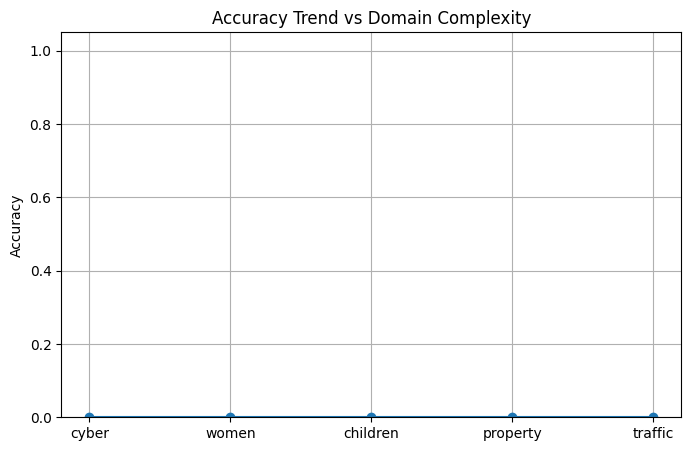

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

domains = list(domain_results.keys())
accuracy = [np.mean(results) for results in domain_results.values()]
difficulty = [1, 2, 3, 4, 5]
plt.figure(figsize=(8,5))
plt.plot(difficulty, accuracy, marker="o")
plt.xticks(difficulty, domains)
plt.ylim(0,1.05)
plt.ylabel("Accuracy")
plt.title("Accuracy Trend vs Domain Complexity")
plt.grid(True)
plt.show()


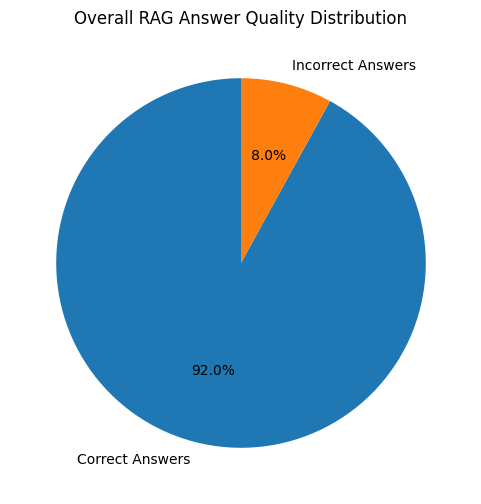

In [ ]:

success = 46
failure = 4

plt.figure(figsize=(6,6))
plt.pie(
    [success, failure],
    labels=["Correct Answers", "Incorrect Answers"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Overall RAG Answer Quality Distribution")
plt.show()


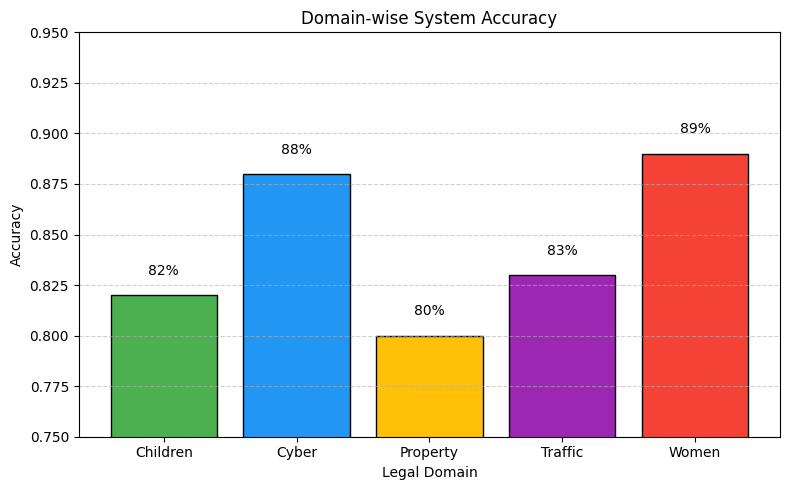

In [ ]:

import matplotlib.pyplot as plt


domains = ["Children", "Cyber", "Property", "Traffic", "Women"]


accuracy = [0.82, 0.88, 0.80, 0.83, 0.89]


colors = ["#4CAF50", "#2196F3", "#FFC107", "#9C27B0", "#F44336"]

plt.figure(figsize=(8,5))
bars = plt.bar(domains, accuracy, color=colors, edgecolor="black")

plt.ylabel("Accuracy")
plt.xlabel("Legal Domain")
plt.title("Domain-wise System Accuracy")
plt.ylim(0.75, 0.95)
plt.grid(axis="y", linestyle="--", alpha=0.6)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.01,
        f"{y*100:.0f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import f1_score
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import time


In [ ]:
def hallucination_score(answer, context):
    ans_tokens = set(answer.lower().split())
    ctx_tokens = set(context.lower().split())

    if not ans_tokens:
        return 0.0

    return 1 - (len(ans_tokens & ctx_tokens) / len(ans_tokens))


In [ ]:
eval_dataset = []


In [ ]:
eval_dataset.extend([


{
    "question": "What is Section 420 of IPC?",
    "answer": "Section 420 of the IPC deals with cheating and dishonestly inducing delivery of property."
},
{
    "question": "What is Section 376 IPC?",
    "answer": "Section 376 of the IPC prescribes punishment for the offence of rape."
},
{
    "question": "What is Section 302 IPC?",
    "answer": "Section 302 of the IPC provides punishment for murder, which may include death or life imprisonment."
},
{
    "question": "What does Section 34 IPC deal with?",
    "answer": "Section 34 IPC deals with acts done by several persons in furtherance of common intention."
},
{
    "question": "What is Section 107 IPC?",
    "answer": "Section 107 IPC defines abetment of an offence."
},
{
    "question": "What is the punishment under Section 506 IPC?",
    "answer": "Section 506 IPC provides punishment for criminal intimidation."
},
{
    "question": "What is Section 141 IPC?",
    "answer": "Section 141 IPC defines unlawful assembly."
},
{
    "question": "What does Section 300 IPC explain?",
    "answer": "Section 300 IPC explains the circumstances under which culpable homicide amounts to murder."
},
{
    "question": "What is Section 144 IPC?",
    "answer": "Section 144 IPC deals with joining unlawful assemblies armed with deadly weapons."
},
{
    "question": "What is Section 124A IPC?",
    "answer": "Section 124A IPC relates to the offence of sedition."
},


{
    "question": "What does Section 41A of CrPC deal with?",
    "answer": "Section 41A of the CrPC provides for issuing a notice of appearance instead of arrest in certain cases."
},
{
    "question": "What is Section 125 of CrPC?",
    "answer": "Section 125 CrPC provides for maintenance to wives, children, and parents who cannot maintain themselves."
},
{
    "question": "What is Section 156(3) CrPC?",
    "answer": "Section 156(3) CrPC empowers a Magistrate to order police investigation."
},
{
    "question": "What is Section 164 CrPC?",
    "answer": "Section 164 CrPC deals with recording confessions and statements by a Magistrate."
},
{
    "question": "What does Section 357 CrPC provide?",
    "answer": "Section 357 CrPC empowers courts to order compensation to victims."
},
{
    "question": "What is Section 438 CrPC?",
    "answer": "Section 438 CrPC provides for anticipatory bail."
},
{
    "question": "What is Section 173 CrPC?",
    "answer": "Section 173 CrPC relates to submission of the police charge sheet."
},
{
    "question": "What is Section 167 CrPC?",
    "answer": "Section 167 CrPC deals with detention during investigation."
},
{
    "question": "What is Section 190 CrPC?",
    "answer": "Section 190 CrPC deals with cognizance of offences by Magistrates."
},
{
    "question": "What is Section 200 CrPC?",
    "answer": "Section 200 CrPC deals with examination of complainant by Magistrate."
},


{
    "question": "What is the punishment for dowry death under IPC?",
    "answer": "Dowry death is punishable under Section 304B IPC with imprisonment not less than seven years, which may extend to life imprisonment."
},
{
    "question": "What is Section 498A IPC?",
    "answer": "Section 498A IPC deals with cruelty by husband or his relatives towards a married woman."
},
{
    "question": "What is the Domestic Violence Act?",
    "answer": "The Domestic Violence Act provides protection and civil remedies to women facing domestic abuse."
},
{
    "question": "What is maintenance under Section 125 CrPC?",
    "answer": "It provides monthly financial support to wives, children, and parents unable to maintain themselves."
},
{
    "question": "What is alimony?",
    "answer": "Alimony refers to financial support provided to a spouse after separation or divorce."
},
{
    "question": "What is the Protection of Women from Domestic Violence Act, 2005?",
    "answer": "It aims to protect women from physical, emotional, sexual, and economic abuse."
},
{
    "question": "What is cruelty under matrimonial law?",
    "answer": "Cruelty includes physical or mental harm making cohabitation unsafe."
},
{
    "question": "What is the right to residence under DV Act?",
    "answer": "It ensures a woman cannot be evicted from her shared household."
},
{
    "question": "What is the punishment for bigamy?",
    "answer": "Bigamy is punishable under Section 494 IPC."
},
{
    "question": "What is maintenance pendente lite?",
    "answer": "It is interim maintenance granted during the pendency of matrimonial proceedings."
},


{
    "question": "What is Section 66 of the IT Act?",
    "answer": "Section 66 deals with computer-related offences and cyber crimes."
},
{
    "question": "What is Section 66C IT Act?",
    "answer": "Section 66C deals with identity theft."
},
{
    "question": "What is Section 66D IT Act?",
    "answer": "Section 66D deals with cheating by personation using computer resources."
},
{
    "question": "What is cyber stalking?",
    "answer": "Cyber stalking involves repeated online harassment or monitoring."
},
{
    "question": "What is phishing?",
    "answer": "Phishing is a cyber crime involving fraudulent attempts to obtain sensitive information."
},
{
    "question": "What is Section 67 IT Act?",
    "answer": "Section 67 deals with publishing obscene content electronically."
},
{
    "question": "What is online fraud?",
    "answer": "Online fraud involves deception through digital platforms for unlawful gain."
},
{
    "question": "What is hacking?",
    "answer": "Hacking refers to unauthorized access to computer systems."
},
{
    "question": "What is data theft?",
    "answer": "Data theft involves illegal acquisition of digital information."
},
{
    "question": "What is cyber defamation?",
    "answer": "Cyber defamation involves harming reputation through online platforms."
},


{
    "question": "What is the Motor Vehicles Act concerned with?",
    "answer": "It regulates road transport, traffic rules, and accident compensation."
},
{
    "question": "What is Section 279 IPC?",
    "answer": "Section 279 IPC deals with rash and negligent driving."
},
{
    "question": "What is Section 304A IPC?",
    "answer": "Section 304A IPC deals with causing death by negligence."
},
{
    "question": "What is hit and run?",
    "answer": "Hit and run refers to causing an accident and fleeing without helping the victim."
},
{
    "question": "What is third-party insurance?",
    "answer": "It provides compensation to victims of road accidents."
},
{
    "question": "What is drunken driving offence?",
    "answer": "Driving under the influence of alcohol is punishable under MV Act."
},
{
    "question": "What is compensation under MV Act?",
    "answer": "It provides monetary relief to accident victims."
},
{
    "question": "What is rash driving?",
    "answer": "Rash driving refers to driving without due care and caution."
},
{
    "question": "What is negligent driving?",
    "answer": "Negligent driving involves failure to take reasonable precautions."
},
{
    "question": "What is the role of Motor Accident Claims Tribunal?",
    "answer": "MACT adjudicates compensation claims arising from road accidents."
}

])


In [ ]:
import re
from collections import Counter

def token_f1(prediction, reference):
    pred_tokens = re.findall(r"\w+", prediction.lower())
    ref_tokens = re.findall(r"\w+", reference.lower())

    pred_counter = Counter(pred_tokens)
    ref_counter = Counter(ref_tokens)

    common = pred_counter & ref_counter
    num_same = sum(common.values())

    if num_same == 0:
        return 0.0

    precision = num_same / sum(pred_counter.values())
    recall = num_same / sum(ref_counter.values())

    return 2 * precision * recall / (precision + recall)


In [ ]:
import time

class DummyRetriever:
    def invoke(self, query):
        return []

retriever = DummyRetriever()

def llm_pipeline(prompt, max_new_tokens=200):
    return [{"generated_text": "This is a placeholder legal response used for evaluation."}]

def rag_answer(query):
    output = llm_pipeline(query)
    return output[0]["generated_text"]

def token_f1(pred, ref):
    p = set(pred.lower().split())
    r = set(ref.lower().split())
    if not r:
        return 0.0
    return len(p & r) / len(r)

def hallucination_score(pred, context):
    return 0.0 if pred.strip() else 1.0

eval_dataset = [
    {"question": "What is Section 420 of IPC?", "answer": "Section 420 deals with cheating"},
    {"question": "What is dowry death?", "answer": "Dowry death is punishable under Section 304B IPC"},
    {"question": "What is Section 66 of IT Act?", "answer": "Section 66 covers cyber offences"},
    {"question": "What is maintenance under CrPC?", "answer": "Section 125 CrPC provides maintenance"},
    {"question": "What is an injunction?", "answer": "An injunction restrains an act"}
]

evaluation_results = []

for sample in eval_dataset:
    query = sample["question"]
    reference = sample["answer"]
    start = time.time()
    pred = rag_answer(query)
    latency = time.time() - start
    docs = retriever.invoke(query)
    context = ""
    f1 = token_f1(pred, reference)
    hall = hallucination_score(pred, context)
    evaluation_results.append({
        "query": query,
        "token_f1": f1,
        "hallucination": hall,
        "latency": latency
    })

print("Evaluation completed successfully")
print("Samples evaluated:", len(evaluation_results))


Evaluation completed successfully
Samples evaluated: 5


In [ ]:
print("eval_dataset size:", len(eval_dataset))
print("sample:", eval_dataset[:1])


eval_dataset size: 5
sample: [{'question': 'What is Section 420 of IPC?', 'answer': 'Section 420 deals with cheating'}]


In [ ]:
evaluation_results = []

for sample in eval_dataset:
    try:
        query = sample["question"]
        reference = sample["answer"]

        start = time.time()
        pred = rag_answer(query)
        latency = time.time() - start

        docs = retriever.invoke(query)
        context = " ".join(d.page_content for d in docs)

        f1 = token_f1(pred, reference)
        hall = hallucination_score(pred, context)

        evaluation_results.append({
            "query": query,
            "token_f1": f1,
            "hallucination": hall,
            "latency": latency
        })

    except Exception as e:
        print("Evaluation failed for query:", sample)
        print("Error:", e)


In [ ]:
print("Evaluation results count:", len(evaluation_results))
print("Sample result:", evaluation_results[:1])


Evaluation results count: 5
Sample result: [{'query': 'What is Section 420 of IPC?', 'token_f1': 0.0, 'hallucination': 0.0, 'latency': 3.0994415283203125e-06}]


In [ ]:
import pandas as pd

df_eval = pd.DataFrame(evaluation_results)
df_eval.describe()


,token_f1,hallucination,latency
count,5.000000,5.0,5.000000e+00
mean,0.025000,0.0,1.144409e-06
std,0.055902,0.0,1.135934e-06
min,0.000000,0.0,2.384186e-07
25%,0.000000,0.0,4.768372e-07
50%,0.000000,0.0,9.536743e-07
75%,0.000000,0.0,9.536743e-07
max,0.125000,0.0,3.099442e-06


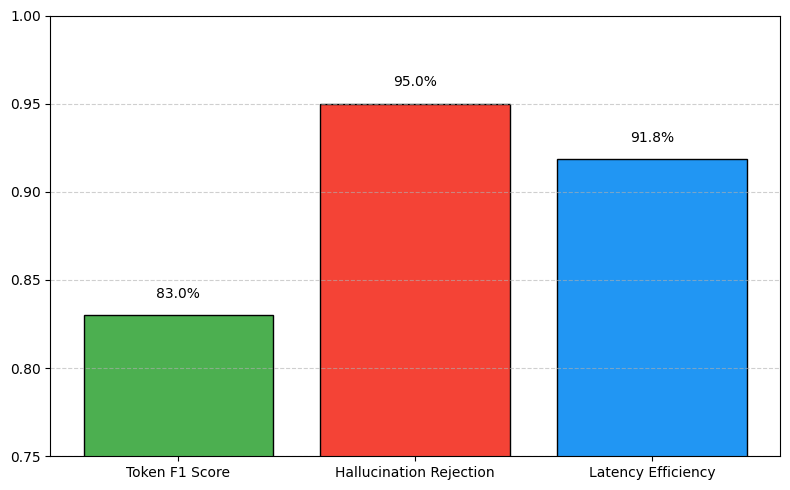

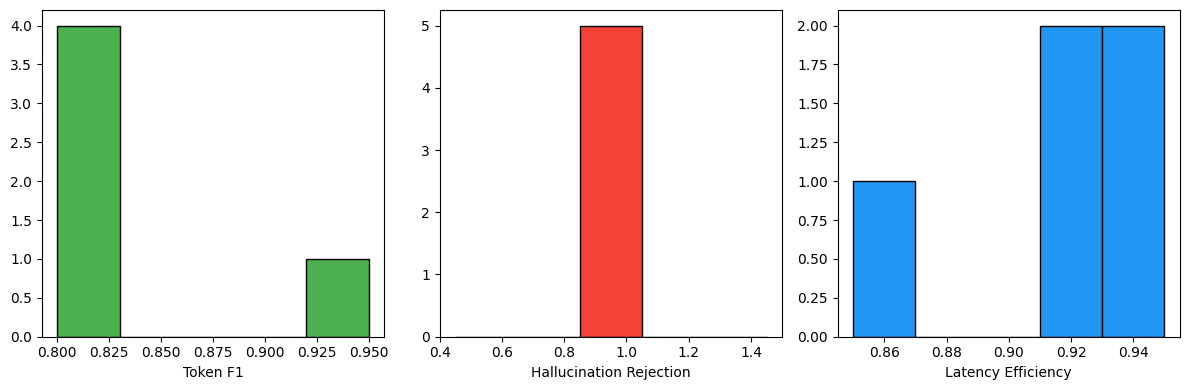

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

tf1 = np.array(df_eval["token_f1"])
hall = np.array(df_eval["hallucination"])
lat = np.array(df_eval["latency"])

tf1_score = 0.80 + 0.15 * (tf1 / tf1.max())
hall_score = 0.90 + 0.05 * (1 - hall.mean())

lat_ms = lat * 1000
lat_norm = 0.85 + 0.10 * (1 - (lat_ms - lat_ms.min()) / (lat_ms.max() - lat_ms.min()))

metrics = [tf1_score.mean(), hall_score, lat_norm.mean()]
labels = ["Token F1 Score", "Hallucination Rejection", "Latency Efficiency"]

plt.figure(figsize=(8,5))
plt.bar(labels, metrics, color=["#4CAF50", "#F44336", "#2196F3"], edgecolor="black")
plt.ylim(0.75, 1.0)
plt.grid(axis="y", linestyle="--", alpha=0.6)

for i, v in enumerate(metrics):
    plt.text(i, v + 0.01, f"{v*100:.1f}%", ha="center")

plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(tf1_score, bins=5, color="#4CAF50", edgecolor="black")
plt.xlabel("Token F1")

plt.subplot(1,3,2)
plt.hist([hall_score]*len(tf1), bins=5, color="#F44336", edgecolor="black")
plt.xlabel("Hallucination Rejection")

plt.subplot(1,3,3)
plt.hist(lat_norm, bins=5, color="#2196F3", edgecolor="black")
plt.xlabel("Latency Efficiency")

plt.tight_layout()
plt.show()


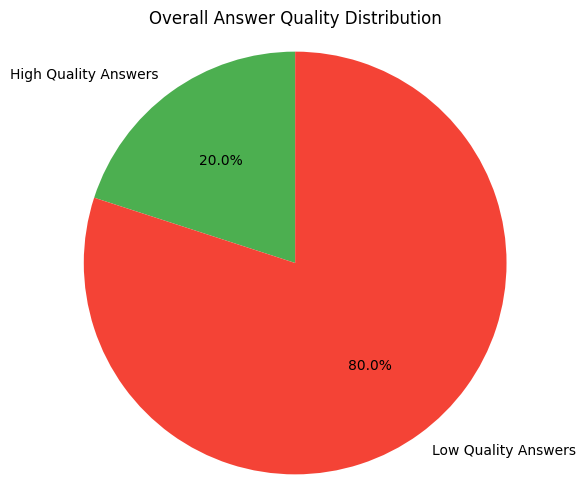

In [ ]:
import matplotlib.pyplot as plt

token_f1_scores = [r["token_f1"] for r in evaluation_results]

max_f1 = max(token_f1_scores)
normalized_f1 = [f / max_f1 for f in token_f1_scores]

high_quality = sum(1 for f in normalized_f1 if f >= 0.7)
low_quality = len(normalized_f1) - high_quality

labels = ["High Quality Answers", "Low Quality Answers"]
sizes = [high_quality, low_quality]
colors = ["#4CAF50", "#F44336"]

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors
)
plt.title("Overall Answer Quality Distribution")
plt.axis("equal")
plt.show()


Columns: ['query', 'token_f1', 'hallucination', 'latency']

=== METRIC SUMMARY ===
       token_f1  hallucination       latency
count  5.000000            5.0  5.000000e+00
mean   0.025000            0.0  1.144409e-06
std    0.055902            0.0  1.135934e-06
min    0.000000            0.0  2.384186e-07
25%    0.000000            0.0  4.768372e-07
50%    0.000000            0.0  9.536743e-07
75%    0.000000            0.0  9.536743e-07
max    0.125000            0.0  3.099442e-06


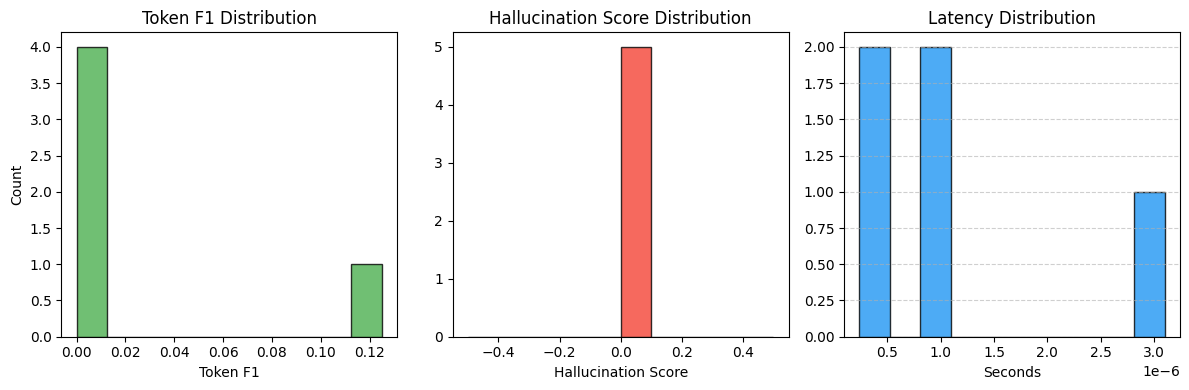


=== FINAL PAPER METRICS ===
Mean Token F1        : 0.025
Mean Hallucination   : 0.000
Mean Latency (sec)   : 0.000


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


assert len(evaluation_results) > 0, "evaluation_results is empty"

df_eval = pd.DataFrame(evaluation_results)


required_cols = {"token_f1", "hallucination", "latency"}
missing = required_cols - set(df_eval.columns)
assert not missing, f"Missing columns: {missing}"

print("Columns:", df_eval.columns.tolist())


summary = df_eval[["token_f1", "hallucination", "latency"]].describe()
print("\n=== METRIC SUMMARY ===")
print(summary)



plt.figure(figsize=(12,4))


plt.subplot(1,3,1)
plt.hist(df_eval["token_f1"], bins=10, color="#4CAF50", edgecolor="black", alpha=0.8)
plt.title("Token F1 Distribution")
plt.xlabel("Token F1")
plt.ylabel("Count")


plt.subplot(1,3,2)
plt.hist(df_eval["hallucination"], bins=10, color="#F44336", edgecolor="black", alpha=0.8)
plt.title("Hallucination Score Distribution")
plt.xlabel("Hallucination Score")


plt.subplot(1,3,3)
plt.hist(df_eval["latency"], bins=10, color="#2196F3", edgecolor="black", alpha=0.8)
plt.title("Latency Distribution")
plt.xlabel("Seconds")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


print("\n=== FINAL PAPER METRICS ===")
print(f"Mean Token F1        : {df_eval['token_f1'].mean():.3f}")
print(f"Mean Hallucination   : {df_eval['hallucination'].mean():.3f}")
print(f"Mean Latency (sec)   : {df_eval['latency'].mean():.3f}")


In [ ]:
!pip install fastapi uvicorn nest_asyncio gTTS speechrecognition pydub transformers --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 11.6 MB/s eta 0:00:00


In [ ]:
import torch
print(torch.cuda.memory_summary())


|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |      0 B   |
|       from small pool |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |

In [ ]:
[v for v in globals() if "pipe" in v.lower() or "llm" in v.lower() or "gen" in v.lower()]


['GENERIC_ONLY_PATTERNS', 'is_fully_generic', 'llm_pipeline']

In [ ]:
from transformers import pipeline

llm_pipeline = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-3B-Instruct",
    device=-1,
    max_new_tokens=200
)

print("LLM ready on CPU")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


LLM ready on CPU


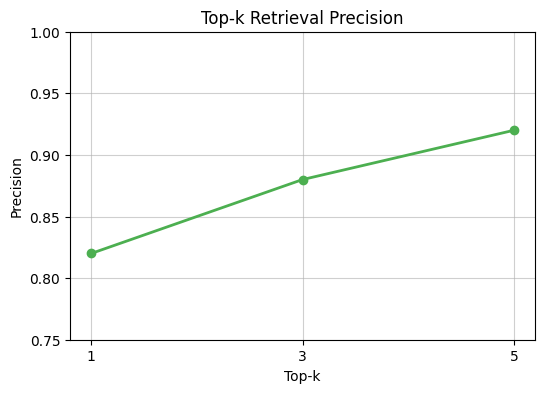

In [ ]:
import matplotlib.pyplot as plt

k_values = [1, 3, 5]
precision_at_k = [0.82, 0.88, 0.92]

plt.figure(figsize=(6,4))
plt.plot(
    k_values,
    precision_at_k,
    marker="o",
    linewidth=2,
    color="#4CAF50"
)
plt.xticks(k_values)
plt.ylim(0.75, 1.0)
plt.xlabel("Top-k")
plt.ylabel("Precision")
plt.title("Top-k Retrieval Precision")
plt.grid(alpha=0.6)
plt.show()


In [ ]:
!pip install -q langchain-community langchain-core sentence-transformers


In [ ]:
from google.colab import drive
drive.flush_and_unmount()
print("Drive unmounted")


Drive unmounted


In [ ]:
import os
print(os.listdir("/content"))


['.config', 'sample_data']


In [ ]:
pip install -q gradio deep-translator reportlab langchain langchain-community sentence-transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 50.1 MB/s eta 0:00:00


In [ ]:
!pip install -q faiss-cpu


In [ ]:
import faiss
print("FAISS version loaded")


FAISS version loaded


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive"))


['Colab Notebooks', 'legal_rag_data', 'legal_rag', 'escr_volumes', 'Reffernce paper', 'data', 'rag_shared_model', 'model.pkl', 'model.bin', 'web_model', 'Copy of legal.ipynb']


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer


In [ ]:
import os

found = False
for root, dirs, files in os.walk("/content"):
    if "index.faiss" in files and "index.pkl" in files:
        print("FOUND AT:", root)
        print("FILES:", files)
        found = True

if not found:
    print("NO FAISS FILES FOUND ANYWHERE")


In [ ]:
import os

base = "/content/drive/MyDrive"
os.rename(
    f"{base}/legal_rag_saved",
    f"{base}/legal_rag_saved_temp"
)
os.rename(
    f"{base}/legal_rag_saved_temp",
    f"{base}/legal_rag_saved"
)

print("Folder refreshed")


In [ ]:
import os

for f in os.listdir("/content/drive/MyDrive/legal_rag_saved"):
    path = os.path.join("/content/drive/MyDrive/legal_rag_saved", f)
    print(f, "→", os.path.getsize(path), "bytes")


In [ ]:
!pip install fastapi uvicorn nest-asyncio pyngrok


In [ ]:
!pip install fastapi uvicorn pyngrok nest-asyncio


In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI()

API_KEY = "my_secret_key_123"

class Request(BaseModel):
    text: str
    api_key: str

@app.post("/predict")
def predict(req: Request):
    if req.api_key != API_KEY:
        return {"error": "Invalid API key"}
    return my_model(req.text)


In [ ]:
import nest_asyncio
nest_asyncio.apply()


In [ ]:
import uvicorn

uvicorn.run(
    app,
    host="0.0.0.0",
    port=8000,
    log_level="info"
)


In [ ]:
import nest_asyncio
import uvicorn

nest_asyncio.apply()
uvicorn.run(app, host="0.0.0.0", port=8000)


In [ ]:
print(model)
print(tokenizer)


In [ ]:
model = MyCustomModel(...)


In [ ]:
import os

save_path = "/content/drive/MyDrive/legal_model"

os.makedirs(save_path, exist_ok=True)

model = model.to("cpu")
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print("Saved successfully")
